<a href="https://colab.research.google.com/github/nguyenxuandinhit/TH_Deep_Learning/blob/main/Deep_Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler

# Tải bộ dataset CIFAR10 có sẵn trong keras
cifar10 = tf.keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước dữ liệu gốc:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Kích thước dữ liệu gốc:
(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [9]:
# Reshape dữ liệu từ 3D (hoặc 4D tính cả batch) thành 2D array [cite: 160]
# X_train gốc có shape (50000, 32, 32, 3), ta chuyển thành (50000, 3072)
X_train = X_train.reshape(50000, 3072)
X_test = X_test.reshape(10000, 3072)

# Feature scaling [cite: 162]
# Tương tự code mẫu, ta dùng MinMaxScaler để đưa giá trị pixel về khoảng [0, 1] [cite: 135]
minmax = MinMaxScaler()
X_train = minmax.fit_transform(X_train)
X_test = minmax.transform(X_test)

print('Number of classes: ', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))

Number of classes:  10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [10]:
# Khởi tạo mô hình [cite: 249]
model = Sequential()

# Thêm hidden layer đầu tiên với hàm kích hoạt ReLU [cite: 252, 53]
model.add(Dense(input_dim=X_train.shape[1], units=256, kernel_initializer='uniform', activation='relu'))

# Thêm hidden layer thứ hai (Tùy chọn, để tăng cường khả năng học cho ảnh màu phức tạp)
model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))

# Thêm output layer với hàm softmax cho bài toán phân lớp (10 nhãn CIFAR10) [cite: 254, 446]
model.add(Dense(units=10, kernel_initializer='uniform', activation='softmax'))

# Compile neural network với Optimizer Adam và hàm Loss để đánh giá [cite: 255, 76, 79]
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Xem tóm tắt mô hình [cite: 256]
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Huấn luyện mô hình
model_fit = model.fit(X_train, y_train, validation_split=0.1, epochs=20, verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.3234 - loss: 1.8548 - val_accuracy: 0.3724 - val_loss: 1.7497
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.3959 - loss: 1.6786 - val_accuracy: 0.4084 - val_loss: 1.6569
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4236 - loss: 1.6000 - val_accuracy: 0.4330 - val_loss: 1.5919
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4468 - loss: 1.5479 - val_accuracy: 0.4270 - val_loss: 1.5979
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4583 - loss: 1.5085 - val_accuracy: 0.4378 - val_loss: 1.5588
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.4729 - loss: 1.4758 - val_accuracy: 0.4652 - val_loss: 1.4977
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.4785 - loss: 1.4583 - val_accuracy: 0.4720 - val_loss: 1.4808
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4883 -

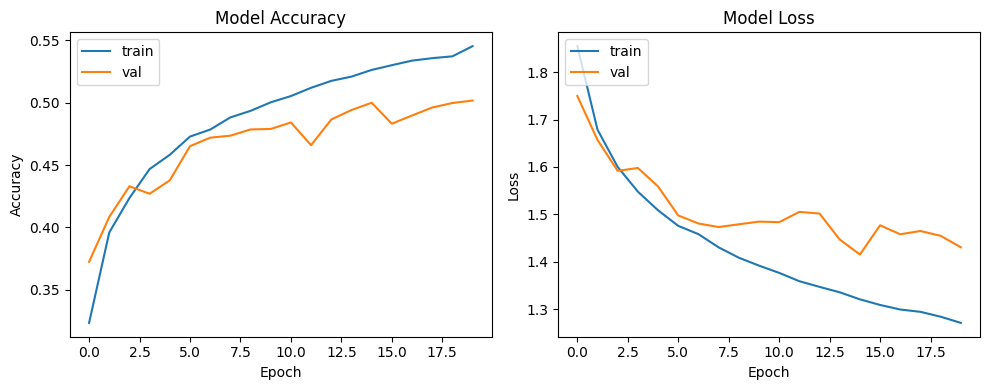

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Nhãn dự đoán: 3
Nhãn thực tế: 3


In [12]:
# Vẽ biểu đồ Accuracy [cite: 349]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

# Vẽ biểu đồ Loss [cite: 373]
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')

plt.tight_layout()
plt.show()

# Dự báo thử 1 ảnh mới trong tập test [cite: 395]
print("Nhãn dự đoán:", np.argmax(model.predict(X_test)[0]))
print("Nhãn thực tế:", y_test[0][0])